## **Notebook PC#04**
## Convolutional classifier for MNIST and CIFAR-10 databases.
**Professor:** Fernando J. Von Zuben <br>
**Cursos:** IA353A / EG453A (FEEC/Unicamp) - 1s2026 <br>
**Aluno(a):** Daniele Souza Gonçalves **RA:** 248029 <br>
**Aluno(a):** Joao Lucas Morais Ortiz **RA:** 297611 <br>


### Configuration Settings - MNIST

In [1]:
batch_size = 128 # Batch-Size
num_classes = 10 # Number of Class
epochs = 10 # Number of epoch

In [2]:
import tensorflow as tf
import os
mnist = tf.keras.datasets.mnist

(x_train, y_train),(x_test, y_test) = mnist.load_data()

# Reshape to be [samples][width][height][channels]
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)

x_train, x_test = x_train / 255.0, x_test / 255.0

print('x_train shape:', x_train.shape)
print(x_train.shape[0], 'train samples')
print(x_test.shape[0], 'test samples')

# convert class vectors into binary class matrices
y_train = tf.keras.utils.to_categorical(y_train, num_classes)
y_test = tf.keras.utils.to_categorical(y_test, num_classes)

print('y_train shape:', y_train.shape)

model = tf.keras.models.Sequential()
model.add(tf.keras.Input(shape=(28, 28, 1)))
model.add(tf.keras.layers.Conv2D(32, kernel_size=(3, 3),activation='relu'))
model.add(tf.keras.layers.Conv2D(64, (3, 3), activation='relu'))
model.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2)))
model.add(tf.keras.layers.Dropout(0.25))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(64, activation='relu'))
model.add(tf.keras.layers.Dropout(0.5))
model.add(tf.keras.layers.Dense(num_classes, activation='softmax'))

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

x_train shape: (60000, 28, 28, 1)
60000 train samples
10000 test samples
y_train shape: (60000, 10)


2026-04-25 22:28:15.926821: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2026-04-25 22:28:15.926880: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-04-25 22:28:15.926887: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-04-25 22:28:15.927096: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-25 22:28:15.927304: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 26, 26, 32)        320       
                                                                 
 conv2d_1 (Conv2D)           (None, 24, 24, 64)        18496     
                                                                 
 max_pooling2d (MaxPooling2  (None, 12, 12, 64)        0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 12, 12, 64)        0         
                                                                 
 flatten (Flatten)           (None, 9216)              0         
                                                                 
 dense (Dense)               (None, 64)                589888    
                                                        

In [3]:
history = model.fit(x_train, y_train, epochs=epochs, batch_size=batch_size, validation_data=(x_test, y_test))

# Evaluate the model on the test data using `evaluate`
print("Evaluate on test data")
results = model.evaluate(x_test, y_test)
print("test loss, test acc:", results)

# Saving the model to disk
model_json = model.to_json()
json_file = open("model_CNN_MNIST.json", "w")
json_file.write(model_json)
json_file.close()
model.save_weights("model_CNN_MNIST.weights.h5")
print("Model saved to disk")
os.getcwd()

Epoch 1/10


2026-04-25 22:28:16.894620: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


469/469 [==============================] - 11s 23ms/step - loss: 0.9353 - accuracy: 0.8456 - val_loss: 0.1482 - val_accuracy: 0.9687
Epoch 2/10
469/469 [==============================] - 10s 22ms/step - loss: 0.3659 - accuracy: 0.9373 - val_loss: 0.1145 - val_accuracy: 0.9767
Epoch 3/10
469/469 [==============================] - 10s 22ms/step - loss: 0.2984 - accuracy: 0.9494 - val_loss: 0.1043 - val_accuracy: 0.9802
Epoch 4/10
469/469 [==============================] - 11s 23ms/step - loss: 0.2489 - accuracy: 0.9556 - val_loss: 0.1108 - val_accuracy: 0.9806
Epoch 5/10
469/469 [==============================] - 11s 22ms/step - loss: 0.2429 - accuracy: 0.9590 - val_loss: 0.0800 - val_accuracy: 0.9839
Epoch 6/10
469/469 [==============================] - 11s 24ms/step - loss: 0.2327 - accuracy: 0.9616 - val_loss: 0.0932 - val_accuracy: 0.9844
Epoch 7/10
469/469 [==============================] - 11s 24ms/step - loss: 0.2317 - accuracy: 0.9630 - val_loss: 0.0800 - val_accuracy: 0.9843
Epo

'/Users/danielesouza/Desktop/Unicamp/IA353/deeplearning-PG-FEEC/notebooks_PCs01a05_IA353_1s2026'

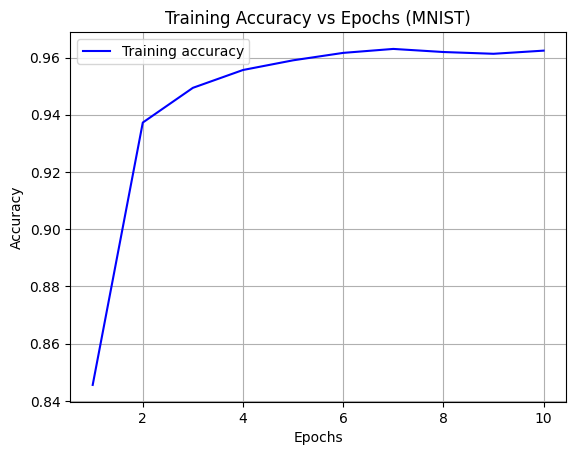

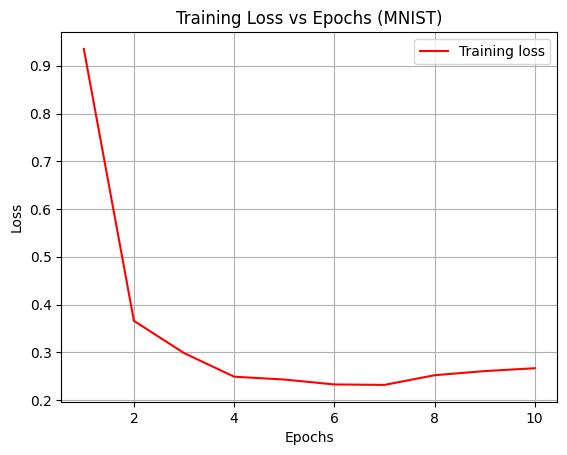

In [4]:
# Behavior along the training process
import matplotlib.pyplot as plt

acc = history.history['accuracy']
loss = history.history['loss']
epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, 'b', label='Training accuracy')
plt.title('Training Accuracy vs Epochs (MNIST)')
plt.legend()
plt.grid()
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.figure()
plt.plot(epochs, loss, 'r', label='Training loss')
plt.title('Training Loss vs Epochs (MNIST)')
plt.legend()
plt.grid()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

### Configuration Settings - CIFAR-10

In [5]:
batch_size = 128 # Batch-Size
num_classes = 10 # Number of Class
epochs = 20 # Number of epoch

In [6]:
import tensorflow as tf
import os

cifar10 = tf.keras.datasets.cifar10

(x_train, y_train),(x_test, y_test) = cifar10.load_data()

x_train, x_test = x_train / 255.0, x_test / 255.0

x_train = x_train.reshape(x_train.shape[0], 32, 32, 3)
x_test = x_test.reshape(x_test.shape[0], 32, 32, 3)

print('x_train shape:', x_train.shape)
print(x_train.shape[0], 'train samples')
print(x_test.shape[0], 'test samples')

# convert class vectors into binary class matrices
y_train = tf.keras.utils.to_categorical(y_train, num_classes)
y_test = tf.keras.utils.to_categorical(y_test, num_classes)

print('y_train shape:', y_train.shape)

model1 = tf.keras.models.Sequential()
model1.add(tf.keras.Input(shape=(32, 32, 3)))
model1.add(tf.keras.layers.Conv2D(32, kernel_size=(3, 3),activation='relu'))
model1.add(tf.keras.layers.Conv2D(64, (3, 3), activation='relu'))
model1.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2)))
model1.add(tf.keras.layers.Dropout(0.25))
model1.add(tf.keras.layers.Flatten())
model1.add(tf.keras.layers.Dense(64, activation='relu'))
model1.add(tf.keras.layers.Dropout(0.5))
model1.add(tf.keras.layers.Dense(10, activation='softmax'))

model1.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model1.summary()

x_train shape: (50000, 32, 32, 3)
50000 train samples
10000 test samples
y_train shape: (50000, 10)
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_2 (Conv2D)           (None, 30, 30, 32)        896       
                                                                 
 conv2d_3 (Conv2D)           (None, 28, 28, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 14, 14, 64)        0         
 g2D)                                                            
                                                                 
 dropout_2 (Dropout)         (None, 14, 14, 64)        0         
                                                                 
 flatten_1 (Flatten)         (None, 12544)             0         
                                                                 
 dense_2 (Dense)    

In [7]:
history1 = model1.fit(x_train, y_train, epochs=epochs, batch_size=batch_size, validation_data=(x_test, y_test))

# Evaluate the model on the test data using `evaluate`
print("Evaluate on test data")
results1 = model1.evaluate(x_test, y_test)
print("test loss, test acc:", results1)

# Saving the model to disk
model_json = model1.to_json()
json_file = open("model_CNN_CIFAR10.json", "w")
json_file.write(model_json)
json_file.close()
model1.save_weights("model_CNN_CIFAR10.weights.h5")
print("Model saved to disk")
os.getcwd()

Epoch 1/20
391/391 [==============================] - 11s 28ms/step - loss: 2.1483 - accuracy: 0.2752 - val_loss: 1.4176 - val_accuracy: 0.4907
Epoch 2/20
391/391 [==============================] - 11s 29ms/step - loss: 1.6227 - accuracy: 0.4152 - val_loss: 1.2983 - val_accuracy: 0.5400
Epoch 3/20
391/391 [==============================] - 11s 27ms/step - loss: 1.4851 - accuracy: 0.4638 - val_loss: 1.2246 - val_accuracy: 0.5732
Epoch 4/20
391/391 [==============================] - 11s 27ms/step - loss: 1.3884 - accuracy: 0.5017 - val_loss: 1.1424 - val_accuracy: 0.5909
Epoch 5/20
391/391 [==============================] - 10s 26ms/step - loss: 1.3483 - accuracy: 0.5197 - val_loss: 1.1204 - val_accuracy: 0.6038
Epoch 6/20
391/391 [==============================] - 11s 29ms/step - loss: 1.3197 - accuracy: 0.5293 - val_loss: 1.1387 - val_accuracy: 0.5990
Epoch 7/20
391/391 [==============================] - 10s 26ms/step - loss: 1.2915 - accuracy: 0.5378 - val_loss: 1.0867 - val_accuracy:

'/Users/danielesouza/Desktop/Unicamp/IA353/deeplearning-PG-FEEC/notebooks_PCs01a05_IA353_1s2026'

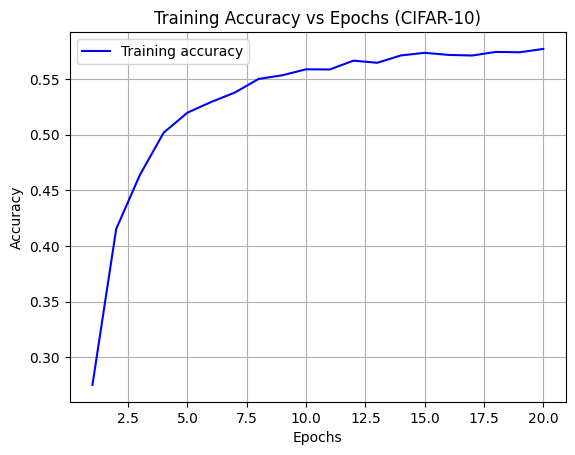

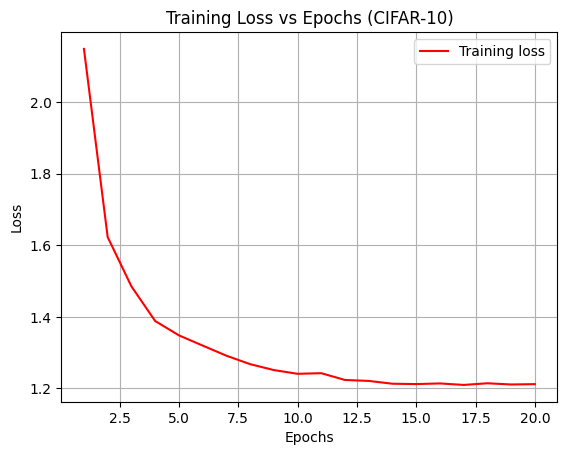

In [8]:
# Behavior along the training process
import matplotlib.pyplot as plt

acc = history1.history['accuracy']
loss = history1.history['loss']
epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, 'b', label='Training accuracy')
plt.title('Training Accuracy vs Epochs (CIFAR-10)')
plt.legend()
plt.grid()
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.figure()
plt.plot(epochs, loss, 'r', label='Training loss')
plt.title('Training Loss vs Epochs (CIFAR-10)')
plt.legend()
plt.grid()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

In [9]:
# Summary of the obtained results for the MNIST database
classifier1 = 'Linear           '
classifier2 = 'ELM              '
classifier3 = 'MLP              '
classifier4 = 'CNN              '
print('--------------------------------------------------')
print('|       Accuracy for the MNIST database          |')
print('--------------------------------------------------')
print('|Classifier type \t Accuracy                |')
print('--------------------------------------------------')
print('| %s: \t\t\t%f |'% (classifier1,0.8617))
print('| %s: \t\t\t%f |'% (classifier2,0.9432))
print('| %s: \t\t\t%f |'% (classifier3,0.9180))
print('| %s: \t\t\t%f |'% (classifier4,0.9845))
print('--------------------------------------------------')

--------------------------------------------------
|       Accuracy for the MNIST database          |
--------------------------------------------------
|Classifier type 	 Accuracy                |
--------------------------------------------------
| Linear           : 			0.861700 |
| ELM              : 			0.943200 |
| MLP              : 			0.918000 |
| CNN              : 			0.984500 |
--------------------------------------------------


In [10]:
# Summary of the obtained results for the CIFAR10 database
classifier1 = 'Linear           '
classifier2 = 'ELM              '
classifier3 = 'MLP              '
classifier4 = 'CNN              '
print('--------------------------------------------------')
print('|      Accuracy for the CIFAR10 database         |')
print('--------------------------------------------------')
print('|Classifier type \t Accuracy                |')
print('--------------------------------------------------')
print('| %s: \t\t\t%f |'% (classifier1,0.4078))
print('| %s: \t\t\t%f |'% (classifier2,0.4739))
print('| %s: \t\t\t%f |'% (classifier3,0.2649))
print('| %s: \t\t\t%f |'% (classifier4,0.6502))
print('--------------------------------------------------')

--------------------------------------------------
|      Accuracy for the CIFAR10 database         |
--------------------------------------------------
|Classifier type 	 Accuracy                |
--------------------------------------------------
| Linear           : 			0.407800 |
| ELM              : 			0.473900 |
| MLP              : 			0.264900 |
| CNN              : 			0.650200 |
--------------------------------------------------


O dataset MNIST, em relação ao CIFAR-10, possui menor complexidade, pois trata-se de dígitos isolados e centralizados, enquanto o CIFAR-10 possui uma grande variabilidade de objetos representados, cores, poses, etc. Dessa forma, é compreensível que os resultados de treinamento para o MNIST tenham sido muito superiores.

Para o caso do MNIST, vemos que os quatro tipos de máquina de aprendizado conseguiram um bom desempenho, sendo a CNN a que se saiu melhor. Isso pode ser explicado pelo fato de que a CNN não achata a imagem em um vetor unidimensional. Diferente do classificador linear estático, a CNN, por construção, consegue extrair múltiplos protótipos locais por classe usando seus filtros, conseguindo assim manter a relação espacial dos pixels e alavancar o desempenho.

Já para o CIFAR-10, vemos que o desempenho dos modelos variou mais, sendo a MLP a com o pior desempenho (cerca de 26% de acurácia). Isso pode ser explicado pelo fato de que a rede tenta interpretar cada pixel isoladamente ao invés de compreender a estrutura da imagem, diferente das CNNs, que obtiveram o melhor desempenho (embora ainda possam melhorar com o aumento da complexidade do modelo).

Já o classificador linear e as ELMs, apesar de não terem um desempenho muito satisfatório, se saíram bem melhor do que a MLP. Isso indica que, para imagens complexas sem o tratamento espacial adequado, a otimização iterativa por gradiente descendente (usada na MLP) se perde e trava em mínimos locais ruins, enquanto as soluções matemáticas diretas (usadas pelo Linear e ELM) conseguem contornar esse problema.